# Swin Transformer

**0 前言**<br>
&nbsp;&nbsp;&nbsp;&nbsp;0.1 Swin Transformer为什么会被提出？<br>
&nbsp;&nbsp;&nbsp;&nbsp;0.2 它主要想解决ViT的什么问题？<br>

**1 Swin Transformer的核心处理机制**<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.1 Window Attention在做什么？<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.2 Shifted Window为什么能建立跨窗口连接？<br>
&nbsp;&nbsp;&nbsp;&nbsp;1.3 W-MSA与SW-MSA是如何交替工作的？<br>

<font color="red">**2 Swin Transformer的整体框架**</font><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1 从Patch Partition到Linear Embedding<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.2 为什么它是层次化Transformer？<br>
&nbsp;&nbsp;&nbsp;&nbsp;2.3 Patch Merging怎样实现尺度变化？<br>

**3 Swin Transformer的完整流程**<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1 一张图进入Swin后会经历哪些步骤？<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2 各个Stage中的特征图尺寸如何变化？<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3 最后如何得到视觉任务需要的输出表示？<br>

**4 学习Swin时最该抓住的几个点**<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1 它和ViT最本质的区别是什么？<br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2 “局部计算 + 跨窗连接 + 层次化表示”该如何整体理解？<br>


## 2 Swin Transformer的整体框架

前一章主要讲的是 Swin Transformer 的**局部注意力机制**，也就是：窗口内怎么计算、窗口为什么要平移、以及 `W-MSA` 和 `SW-MSA` 怎样交替工作。

但如果只理解这些，还没有真正看清 Swin 的全貌。因为 Swin 真正重要的地方，不只是“注意力被限制在局部窗口里”，而是它把这些局部注意力模块，放进了一个**层次化、分阶段演化的视觉主干**中。

这一章就专门来看这条主线。核心问题有三个：

- 输入图像最开始是怎样被组织成 Swin 可以处理的 token 的
- 为什么说它不是一个固定分辨率的 Transformer，而是一个层次化 Transformer
- `Patch Merging` 到底在框架中起什么作用，它怎样推动尺度变化

所以可以把这一章理解成：**把前面讲过的局部注意力机制，重新放回整个 Swin 的数据流和结构骨架中。**

其中，`2.1` 先解决最开始的输入组织问题，也就是从 `Patch Partition` 到 `Linear Embedding` 这一步究竟发生了什么。

### 2.1 从Patch Partition到Linear Embedding

要理解 Swin Transformer 的整体框架，第一步必须先看清：**一张输入图像在进入第一个 Swin stage 之前，到底是怎样变成一批 token 的。**

这里最容易混淆的地方是，论文里连续出现了两个看起来很像的词：

- `Patch Partition`
- `Linear Embedding`

很多人会把它们当成同一件事，但实际上它们对应的是两个不同步骤：

- `Patch Partition` 负责把图像按空间位置切成小块
- `Linear Embedding` 负责把每个小块变成固定维度的向量表示

也就是说，前者是在做**空间重组**，后者是在做**特征映射**。只有把这两个动作分开，后面的整体数据流才不会混。

#### 2.1.1 Patch Partition到底在做什么？

先从 `Patch Partition` 开始。

Swin 的输入是一张图像，通常可以记成：

$$
x \in \mathbb{R}^{H \times W \times 3}
$$

这里 `H` 和 `W` 分别是图像的高和宽，`3` 是 RGB 通道数。

Swin 不会直接把整张图丢进 Transformer，而是先把图像切成很多个互不重叠的小 patch。论文默认的 patch size 是 `4 × 4`，所以你可以先把它想成：

- 沿高度方向每隔 4 个像素切一次
- 沿宽度方向每隔 4 个像素切一次
- 每个 patch 都是一个 `4 × 4 × 3` 的小图块

如果输入图像大小是 `224 × 224 × 3`，那么切完以后：

$$
224 / 4 = 56
$$

所以高方向有 `56` 个 patch，宽方向也有 `56` 个 patch，总 patch 数量就是：

$$
56 \times 56 = 3136
$$

这一步最本质的作用是：**把原始像素网格重新组织成更粗一级的视觉基本单元。**

这里尤其要注意，`Patch Partition` 本身还没有做“理解”，也没有做注意力，它只是把原图按固定大小切块。换句话说，它解决的是：

**模型后面不再直接以单个像素为处理单位，而是以 `4 × 4` 的局部块为处理单位。**

这和 ViT 的基本思想是一致的，但 Swin 在这里选择了较小的 patch size，这一点非常关键。因为 `4 × 4` 的 patch 比 ViT 常见的 `16 × 16` 更细，所以模型在最开始能保留更多局部空间结构，这也为后面的窗口注意力和层次化尺度变化打下了基础。

#### 2.1.2 为什么切完patch以后还不够？

只把图像切成 patch 还不够，因为 Transformer 并不能直接处理一个“二维小图块”本身。它真正擅长处理的，还是一组**向量表示**。

例如，一个 `4 × 4 × 3` 的 patch，虽然已经是一个局部区域了，但它本质上还是像素值堆出来的小张量，而不是模型内部统一维度的 token 表示。

所以在 `Patch Partition` 之后，还要接上第二步：`Linear Embedding`。

#### 2.1.3 Linear Embedding在做什么？

`Linear Embedding` 的任务很直接：**把每个 patch 转成固定维度的向量 token。**

先看一个 patch 的尺寸。一个 `4 × 4 × 3` 的 patch 一共有：

$$
4 \times 4 \times 3 = 48
$$

个数值。

因此，最自然的第一步是先把这个 patch 展平，变成一个长度为 `48` 的向量。之后，再通过一个线性层把它映射到模型需要的通道维度，比如 Swin-T 里常见的初始维度 `C = 96`。

于是，每个 patch 会经历：

$$
4 \times 4 \times 3 \rightarrow 48 \rightarrow C
$$

如果 `C = 96`，那就表示：每个 patch 最后都变成一个 `96` 维向量。

这样做的意义是：

- patch 仍然保留局部区域的原始内容
- 但它已经被变换成统一维度的 token 表示
- 后面的 Swin block 才能在这些 token 上做窗口注意力和特征更新

所以 `Linear Embedding` 本质上是在回答一个问题：

**怎样把“像素块”翻译成“Transformer 可以处理的 token 向量”？**

#### 2.1.4 这一阶段的张量形状是怎样变化的？

这一点必须讲清，因为后面整个 Swin 的层次化结构都建立在这里。

假设输入图像大小是：

$$
224 \times 224 \times 3
$$

经过 `Patch Partition` 以后，会得到 `56 × 56` 个 patch 网格。注意，这里更适合把它理解成一个二维 patch 网格，而不是立刻只把它看成一条长序列。

因为在 Swin 里，**空间结构会被尽量保留**。这和标准 ViT 很不一样。ViT 往往更早把 patch 直接看成一串 token；而 Swin 更强调后面还要做窗口划分、窗口平移和 patch merging，所以二维布局信息非常重要。

接着，每个 patch 被映射成 `C` 维向量后，张量可以理解成：

$$
56 \times 56 \times C
$$

如果 `C = 96`，那就是：

$$
56 \times 56 \times 96
$$

这时你可以把它理解成：

- 空间分辨率从原来的 `224 × 224` 变成了 `56 × 56`
- 每个空间位置不再对应 3 个 RGB 值，而是对应一个 `96` 维的局部特征向量

这其实非常像 CNN 里“输入图像先被映射成一张较低分辨率、较高通道数的特征图”。只是这里的形成方式，不是卷积层先提特征，而是先做 patch 切分，再做线性映射。

#### 2.1.5 为什么这里要保留二维结构，而不是立刻完全序列化？

这是理解 Swin 整体框架时非常关键的一点。

如果像标准 ViT 那样，一开始就把所有 patch 完全摊平成一条长序列，那么后面的全局注意力当然还能做，但“局部窗口”这件事就不再天然。模型需要额外知道哪些 token 在空间上相邻，哪些 token 属于同一个局部区域。

而 Swin 恰恰是围绕二维空间结构来设计的：

- 窗口划分是在二维特征图上做的
- 窗口平移也是在二维网格上定义的
- `Patch Merging` 更是直接按空间邻域去合并相邻 patch

所以从 `Patch Partition` 到 `Linear Embedding` 这一步，不只是“做出 token”这么简单，更重要的是：

**它把原始图像转换成了一张“适合后续窗口操作和层次化处理”的 patch-level 特征图。**

这就是为什么理解 Swin 的输入阶段时，不能只记“图像被切成 token 了”，还要记住：这些 token 在一开始仍然带着明确的二维排布关系。

#### 2.1.6 这一阶段和后面整体框架的关系是什么？

到这里，可以把 `2.1` 的作用压缩成一句更整体的话：

`Patch Partition + Linear Embedding` 做的事情，就是把输入图像从像素空间，变成 Swin 主干真正开始工作的第一张 patch-level 特征图。

也就是说，从这一刻开始，后面所有的窗口注意力、shifted window、patch merging，处理的都不再是原始像素，而是这张：

$$
\frac{H}{4} \times \frac{W}{4} \times C
$$

的初始特征图。

所以 `2.1` 真正要记住的不是零散细节，而是这一条主线：

1. 原图先被切成 `4 × 4` 的非重叠 patch。
2. 每个 patch 被映射成固定维度的向量。
3. 这些向量仍保持二维网格布局，形成 Swin 的初始特征图。

后面 `2.2` 要进一步回答：为什么这张初始特征图不会一直保持不变，而是会被组织成一个层次化的多 stage 结构。

### 2.2 为什么它是层次化Transformer？

前一节已经讲清楚，Swin 的输入在经过 `Patch Partition + Linear Embedding` 之后，会变成一张：

$$
\frac{H}{4} \times \frac{W}{4} \times C
$$

的初始 patch-level 特征图。

但如果模型后面的所有层都始终在这张固定尺寸的特征图上计算，那么它本质上仍然更接近一种“固定尺度 Transformer”。这并不是 Swin 最关键的地方。

Swin 真正重要的是：**它并不会让特征图的空间尺度和语义粒度一直保持不变，而是把整个主干分成多个 stage，让表示随着层数加深逐步演化。**

这就是“层次化 Transformer”里“层次化”三个字真正指的东西。

下面分几个小点，把这件事拆开来看。



#### 2.2.1 什么叫层次化，不要只理解成“层很多”

很多初学者会把“层次化”误解成“网络层数比较深”。这当然不对，因为普通 ViT 也可以堆很多层，但它未必是层次化的。

这里的层次化，指的是：

**不同深度的表示，不只是内容在更新，连空间分辨率、token 粒度和语义抽象程度也在变化。**

换句话说，前层、中层、后层并不是在同一种表示上重复做同一种加工，而是在处理：

- 越来越粗的空间尺度
- 越来越强的通道表达
- 越来越抽象的语义信息

这和 CNN 的层次结构是很像的。前面的层更接近局部细节，后面的层更接近高层语义；前面的特征图分辨率更高，后面的特征图分辨率更低；但与此同时，后层每个位置携带的信息量会更多。

Swin 的重要意义就在于：**它把这种本来属于 CNN 的层次化视觉建模方式，重新做进了 Transformer 主干里。**



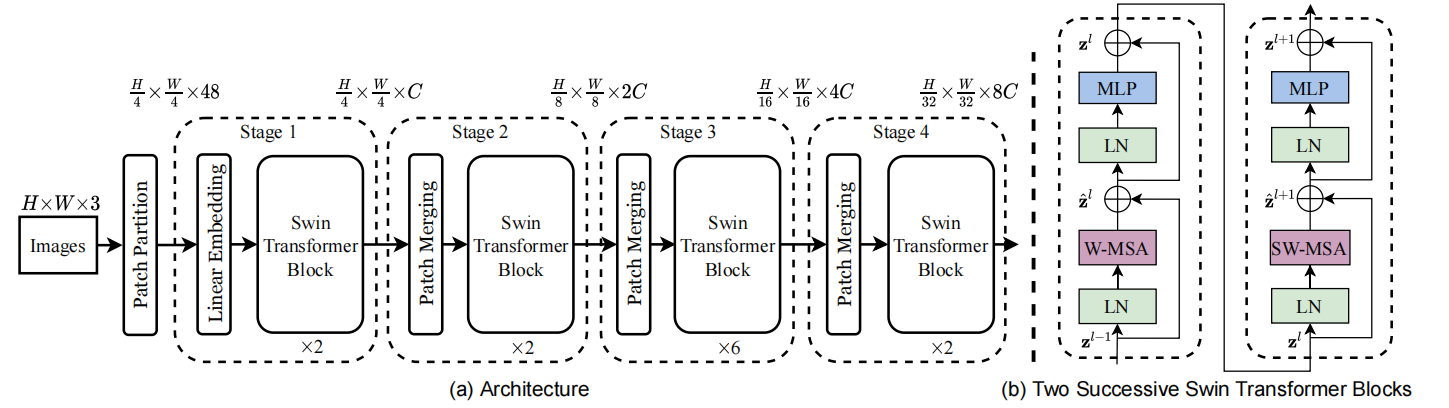


#### 2.2.2 Swin的层次化结构具体长什么样？

Swin 通常把整个网络分成 4 个 stage。可以先把它理解成 4 段连续处理流程，每一段里都有若干个 Swin block，而相邻 stage 之间会发生一次尺度变化。

如果还用前面的输入例子，图像大小是 `224 × 224`，patch size 是 `4 × 4`，初始 embedding dim 是 `C`，那么 4 个 stage 的特征图尺寸大致可以写成：

1. Stage 1: `56 × 56 × C`
2. Stage 2: `28 × 28 × 2C`
3. Stage 3: `14 × 14 × 4C`
4. Stage 4: `7 × 7 × 8C`

这里有两个最重要的变化趋势：

- 空间分辨率逐步下降
- 通道维度逐步上升

也就是说，随着网络变深，特征图会越来越小，但每个位置的特征向量会越来越“厚”。

这个结构乍看很像 CNN 里的金字塔特征提取。实际上，这正是 Swin 之所以适合作为视觉 backbone 的关键原因之一。因为目标检测、分割这类任务，本来就非常依赖这种多 stage、多尺度的主干结构。




#### 2.2.3 为什么空间分辨率要逐步下降？

这个问题必须从两个角度一起看：**计算角度**和**语义角度**。

先看计算角度。

即使 Swin 的注意力被限制在局部窗口里，特征图分辨率如果始终很高，token 数量依然会很多，整网的计算和显存成本还是会越来越重。尤其是越往后层，如果还保留和前层一样密的空间位置，其实并不划算。

再看语义角度。

后层真正关心的，不再只是某个很小局部里有没有边缘、纹理或者短距离联系，而是更大范围的目标结构和更抽象的语义组合。这时，如果仍然让每个很细的位置都单独保留一个 token，就会显得过细，语义组织效率也不高。

所以更自然的做法就是：

- 前层保留高分辨率，先把局部细节建模好
- 后层逐步降低分辨率，让更大范围的信息被汇聚到更少的位置上

这正是层次化视觉主干的典型思路。它不是简单地“省计算”，而是在说：**不同深度本来就应该对应不同粒度的视觉表示。**




#### 2.2.4 为什么通道维度又要逐步增加？

这件事看上去有点反直觉，因为空间位置变少了，为什么每个位置反而要用更多维度去表示？

原因是：**后层虽然位置更少，但每个位置承担的语义复杂度更高了。**

前层的一个位置，也许只需要表达局部边缘、纹理、颜色变化、短距离关系；但到了后层，一个位置往往已经覆盖了更大的感受范围，它需要承载更综合的局部组合、部件关系，甚至更接近整体目标语义的信息。

这时如果通道维度不增加，后层每个 token 的表达能力就会显得不够。于是，Swin 采用了一种很经典的平衡方式：

- 用更少的空间位置来表示更大的区域
- 用更大的通道维度来补足每个位置的表示容量

所以可以把它简单理解成：

**前层强调“位置多、粒度细”，后层强调“位置少、语义浓”。**

这正是 `56 × 56 × C -> 28 × 28 × 2C -> 14 × 14 × 4C -> 7 × 7 × 8C` 这条主线背后的意义。




#### 2.2.5 为什么这种结构特别适合视觉任务？

这是 Swin 和标准 ViT 在整体框架层面最重要的区别之一。

标准 ViT 的典型做法，是把图像切成 patch 后，后面很多层都在固定尺度上处理这批 token。这样做的优点是结构简洁，但它不太像一个传统视觉 backbone。尤其在需要多尺度特征的任务里，它不够自然。

而 Swin 的层次化结构更像 CNN 主干，因此它有几个非常实际的优点：

- 更容易和检测、分割等 dense prediction 框架对接
- 更容易形成不同尺度的特征表示
- 更符合视觉任务从局部到整体的语义演化规律

这里最关键的一点是：Swin 并不是单纯为了模仿 CNN 才做成层次化，而是因为**视觉问题本来就天然需要层次化表示**。Swin 只是把这种需求，用 Transformer 的方式实现出来了。




#### 2.2.6 stage内部和stage之间分别在做什么？

理解这一点以后，整个 Swin 框架会清楚很多。

你可以把它分成两种层级上的工作：

- **stage 内部**：在固定分辨率上，用 `W-MSA` 和 `SW-MSA` 反复建模，更新同一尺度下的表示
- **stage 之间**：通过 `Patch Merging` 改变尺度，把特征图变得更粗，同时把通道做大

也就是说，Swin 并不是每一层都同时做“注意力建模”和“尺度变化”。更准确地说：

- 某一个 stage 内，是“在当前尺度上充分加工”
- 到 stage 边界时，才进入下一层级尺度

这个设计非常像“先在当前分辨率下学够，再做下一次下采样”。因此它的结构既清晰，也很适合形成分阶段的特征金字塔。



### 2.3 Patch Merging怎样实现尺度变化？

前一节已经知道，Swin 的层次化结构不是一句空话，而是会真实地体现在 stage 之间的尺度变化上：

$$
56 \times 56 \times C \rightarrow 28 \times 28 \times 2C \rightarrow 14 \times 14 \times 4C \rightarrow 7 \times 7 \times 8C
$$

但这时还缺最后一个关键问题：**这种变化到底是怎样做出来的？**

Swin 给出的答案就是 `Patch Merging`。

可以先把它理解成一句很直白的话：

**把空间上相邻的几个 patch 合并起来，让空间分辨率下降，同时让每个新位置的表示容量变大。**

也就是说，`Patch Merging` 本质上就是 Swin 在 stage 之间执行的“下采样 + 通道调整”操作。

#### 2.3.1 Patch Merging的基本思路是什么？

先看最核心的直觉。

假设当前某个 stage 的输入特征图大小是：

$$
H \times W \times C
$$

这里每个空间位置都对应一个 `C` 维特征向量。

`Patch Merging` 做的事情，不是再去切新的原始 patch，而是直接在这张已经存在的 patch-level 特征图上操作。它会取出空间上相邻的 `2 × 2` 个位置，把它们合并成一个新的位置。

也就是说，原来四个相邻位置：

- 左上
- 右上
- 左下
- 右下

会被视为一个局部组，然后一起变成下一 stage 中的一个新 token。

因此，空间尺寸会发生非常直接的变化：

$$
H \times W \rightarrow \frac{H}{2} \times \frac{W}{2}
$$

也就是高和宽都减半，空间位置总数变成原来的四分之一。

这一步如果只看空间效果，它和 CNN 里的下采样是很像的：都是让后层表示覆盖更大的感受区域。只不过这里的单位不是像素或卷积响应，而是已经形成的 patch-level token 特征。


#### 2.3.2 它具体是怎样做张量变换的？

这一点是 `Patch Merging` 最核心、也最容易卡住的地方。

假设当前输入特征图是：

$$
H \times W \times C
$$

现在取一个 `2 × 2` 的相邻区域。这个区域里一共有 4 个位置，而每个位置都有一个 `C` 维向量。

那么最直接的做法是：先把这 4 个位置的向量拼接起来。这样一来，一个新的局部组就会得到：

$$
4C
$$

维表示。

所以从局部上看，`Patch Merging` 的第一步其实是：

$$
(C, C, C, C) \rightarrow 4C
$$

这一步要特别注意，它不是做平均，也不是简单相加，而是**先拼接**。也就是说，四个相邻位置各自的信息会先被完整保留下来，然后再交给后续线性变换去重新组织。

接下来，Swin 不会直接把这个 `4C` 维向量原封不动送到下一 stage，而是再接一个线性层，把它从 `4C` 映射到 `2C`。

因此，`Patch Merging` 的完整局部过程可以写成：

$$
2 \times 2 \text{ neighboring tokens} \rightarrow 4C \rightarrow 2C
$$

于是，从整体张量上看，就有：

$$
H \times W \times C \rightarrow \frac{H}{2} \times \frac{W}{2} \times 2C
$$

这就是为什么前面会看到：

- `56 × 56 × C` 变成 `28 × 28 × 2C`
- `28 × 28 × 2C` 变成 `14 × 14 × 4C`
- `14 × 14 × 4C` 变成 `7 × 7 × 8C`

因为每经过一次 `Patch Merging`，空间分辨率减半，而通道维度翻倍。


#### 2.3.3 为什么不是直接保留4C，而是映射到2C？

这是一个很值得单独讲清的问题。

如果把 `2 × 2` 的四个位置拼接起来，确实天然会得到一个 `4C` 维向量。那么为什么 Swin 不直接把下一 stage 的通道设成 `4C`，而还要再压到 `2C`？

原因可以从两个层面理解。

第一，**如果每次都直接保留 `4C`，通道增长会太快。**

空间位置虽然减少了，但如果通道每次都扩大四倍，整网的参数量和计算成本会膨胀得过猛，后续 block 的负担也会明显增大。

第二，**四个相邻位置之间其实存在大量相关性，不需要把所有信息都用完全独立的 `4C` 维保留下来。**

更合理的做法是：先把四个局部位置的信息都拿到，再通过一个线性层学习如何压缩和重组它们，最后输出一个更紧凑但仍然足够强的表示。

所以这里的 `4C -> 2C` 可以理解成一种：

- 先充分收集局部邻域信息
- 再进行受控压缩
- 最后得到更适合下一 stage 的表示

也就是说，`Patch Merging` 不是粗暴地丢信息，而是在做**带学习能力的局部汇聚与压缩**。


#### 2.3.4 从语义角度看，Patch Merging意味着什么？

如果只看公式，`Patch Merging` 很容易被理解成“一个技术性的下采样操作”。但从视觉建模的角度看，它其实对应着一个非常重要的语义变化：

**下一 stage 中的每一个位置，不再只代表原来那一个小 patch，而是开始代表一个更大的局部区域。**

举例来说，在 Stage 1 里，一个位置可能主要对应输入图像中的一个 `4 × 4` patch；而经过一次 `Patch Merging` 之后，Stage 2 中的一个位置，已经是由 4 个相邻位置合并而来，它实际覆盖的原图范围就更大了。

因此，随着 stage 往后推进，模型中的一个 token 不只是“维度变了”，更重要的是：

- 它覆盖的空间区域更大了
- 它整合的局部上下文更多了
- 它所承载的语义也更接近中层或高层概念了

这正是层次化视觉主干想要的效果。前层先看细节，后层逐步把细节组合成更大范围的结构。`Patch Merging` 就是推动这个过程发生的关键节点。


#### 2.3.5 它和stage结构之间是什么关系？

这一点必须放回整体框架里理解。

在 Swin 里，`Patch Merging` 不是每个 block 后面都接一次，而是通常放在 **一个 stage 的末尾**。这意味着它扮演的角色不是“普通层内操作”，而是“stage 到 stage 的过渡模块”。

于是整个流程就会变成：

1. 先在当前分辨率下，用若干个 Swin block 充分建模。
2. 到 stage 结束时，用 `Patch Merging` 做一次尺度变化。
3. 下一 stage 在更低分辨率、更高通道数的表示上继续建模。

这个设计有一个很自然的优点：模型不会在每一层都频繁改变尺度，而是会先在当前尺度上“学够”，再进入下一层级表示。

所以从结构定位上说，`Patch Merging` 更像是 Swin 中的**层级切换开关**。它负责把“当前尺度的特征加工”转成“下一尺度的特征加工”。


#### 2.3.6 它和常见的pooling或卷积下采样有什么相似与不同？

从结果上看，`Patch Merging` 和 CNN 里的 pooling / stride convolution 都会让分辨率下降，所以它们在“结构角色”上是相似的。

但 Swin 的 `Patch Merging` 仍然有自己的特点：

- 它操作的对象不是像素，而是已经形成的 token 特征
- 它不是直接做固定规则的平均或最大值，而是先拼接相邻 token
- 它后面接的是可学习的线性映射，因此信息重组方式是可以学出来的

所以它可以看成一种“Transformer 风格的下采样”。

也就是说，Swin 并没有照搬 CNN 的下采样实现，而是保留了 Transformer 表示的形式，用一种更贴合 token 表示的方法去完成尺度变化。



如果把 `2.3` 压成一句话，那就是：

**`Patch Merging` 通过把 `2 × 2` 的相邻 token 先拼接、再线性映射，实现了“分辨率减半、通道翻倍”的 stage 间尺度变化。**



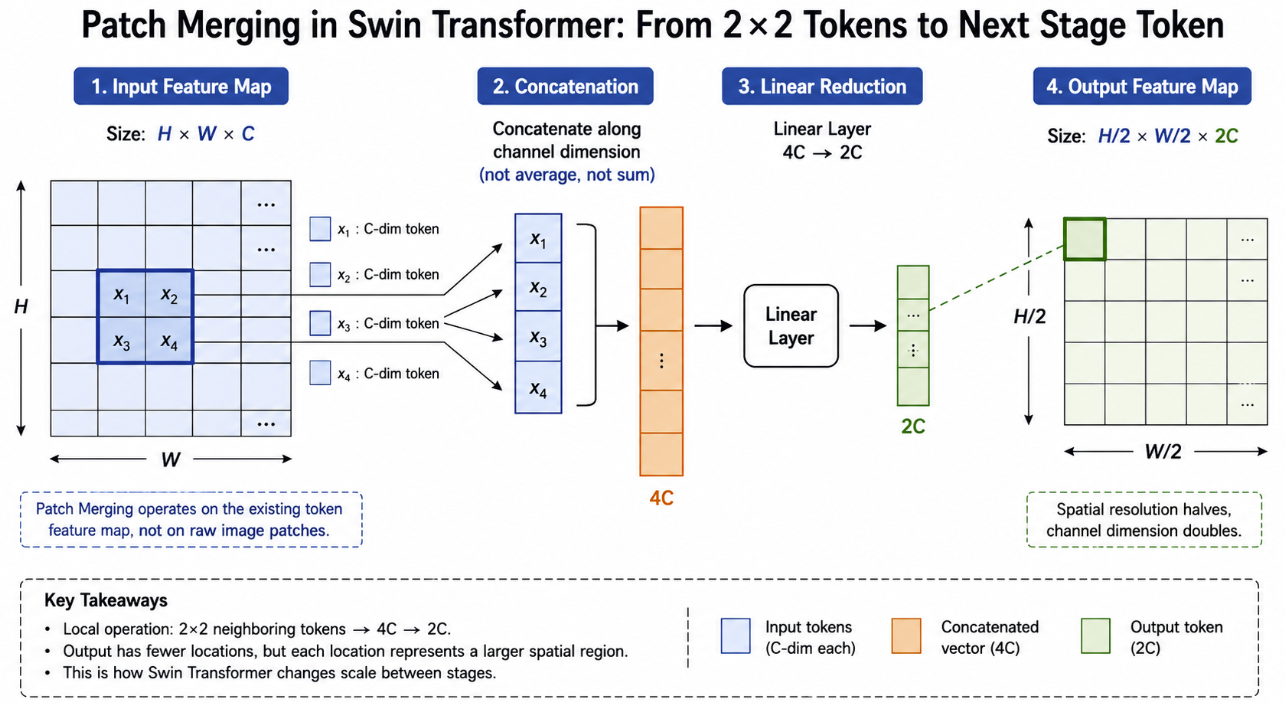